In [13]:
import pandas as pd

df = pd.read_csv('World_Cup_Player_Fouls.csv')  # start from the RAW file, not the broken cleaned one

# Exclude players with 0 minutes played (this removes the division-by-zero rows)
df = df[df['90s'] > 0].copy()

# Keep ONLY pure MF and DF (excludes FW, GK, and all hybrids like FWMF, MFDF)
df = df[df['Pos'].isin(['MF', 'DF'])].copy()

# Now calculate fouls per 90 safely (no more zero-division)
df['fouls_per90'] = df['Fls'] / df['90s']

# Save the ACTUALLY cleaned file
df.to_csv('WC2026_Fouls_Data_Cleaned.csv', index=False)

print(df['Pos'].unique())      # should show only ['MF' 'DF']
print(len(df))                 # should be 636
print(df['fouls_per90'].isna().sum())  # should be 0

['MF' 'DF']
636
0


In [17]:
# =========================================================
# HIT140 Assessment 2 - Task 1 (WRITTEN OUTPUT VERSION)
# Analytic Question: Is there a significant difference in average
# fouls per 90 minutes between midfielders and defenders at the
# FIFA World Cup 2026?
#
# Input: World_Cup_Player_Fouls.csv
# Output: descriptive statistics, confidence intervals, t-test (text only)
# =========================================================
 
import pandas as pd
from scipy import stats
 
# -------------------------------
# LOAD CLEANED DATA
# -------------------------------
df = pd.read_csv('WC2026_Fouls_Data_Cleaned.csv')
print(f"Total players in cleaned dataset: {len(df)}")
print(df['Pos'].value_counts())
 
# Split into the two comparison groups
midfielders = df[df['Pos'] == 'MF']['fouls_per90']
defenders = df[df['Pos'] == 'DF']['fouls_per90']
 
# -------------------------------
# DESCRIPTIVE STATISTICS
# -------------------------------
print("\n=== Descriptive Statistics: Midfielders ===")
print(midfielders.describe())
 
print("\n=== Descriptive Statistics: Defenders ===")
print(defenders.describe())
 
# -------------------------------
# CONFIDENCE INTERVALS (95%)
# -------------------------------
mf_mean, df_mean = midfielders.mean(), defenders.mean()
mf_ci = stats.t.interval(0.95, len(midfielders)-1, loc=mf_mean, scale=stats.sem(midfielders))
df_ci = stats.t.interval(0.95, len(defenders)-1, loc=df_mean, scale=stats.sem(defenders))
 
print(f"\nMidfielders 95% CI: ({mf_ci[0]:.4f}, {mf_ci[1]:.4f})")
print(f"Defenders 95% CI:   ({df_ci[0]:.4f}, {df_ci[1]:.4f})")
 
# -------------------------------
# TWO-SAMPLE T-TEST
# -------------------------------
t_stat, p_value = stats.ttest_ind(midfielders, defenders, equal_var=False)
print(f"\nTwo-sample t-test: t = {t_stat:.4f}, p = {p_value:.6f}")
 
if p_value < 0.05:
    print("Result: statistically significant -> reject H0")
    print("Conclusion: Midfielders and defenders differ significantly in fouls per 90.")
else:
    print("Result: not statistically significant -> fail to reject H0")
    print("Conclusion: No significant difference found between the two groups.")





Total players in cleaned dataset: 636
Pos
MF    337
DF    299
Name: count, dtype: int64

=== Descriptive Statistics: Midfielders ===
count    337.000000
mean       1.351240
std        1.358592
min        0.000000
25%        0.476190
50%        1.176471
75%        1.785714
max       10.000000
Name: fouls_per90, dtype: float64

=== Descriptive Statistics: Defenders ===
count    299.000000
mean       1.117088
std        1.541874
min        0.000000
25%        0.350985
50%        0.943396
75%        1.428571
max       20.000000
Name: fouls_per90, dtype: float64

Midfielders 95% CI: (1.2057, 1.4968)
Defenders 95% CI:   (0.9416, 1.2926)

Two-sample t-test: t = 2.0207, p = 0.043761
Result: statistically significant -> reject H0
Conclusion: Midfielders and defenders differ significantly in fouls per 90.


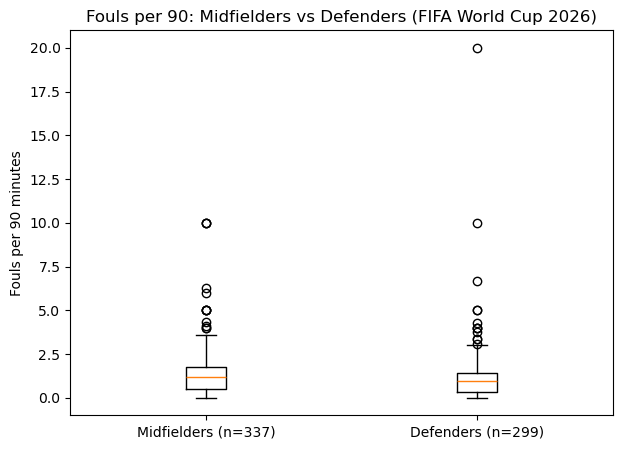

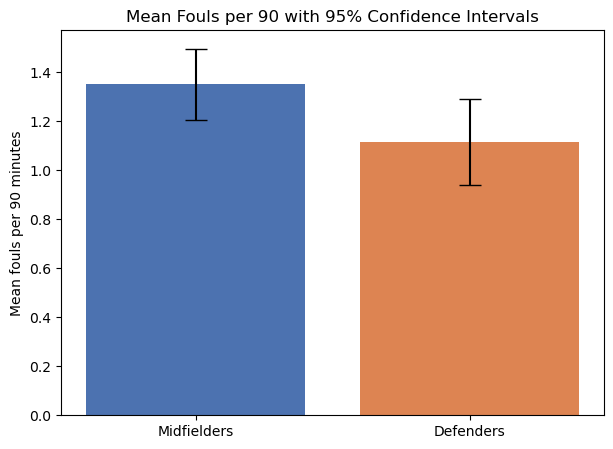

Charts saved as 'Hasibul_WC2026_Fouls_Boxplot.png' and 'Hasibul_WC2026_Fouls_BarCI.png'.


In [15]:
# =========================================================
# HIT140 Assessment 2 - Task 1 (VISUAL / GRAPH OUTPUT VERSION)
# Analytic Question: Is there a significant difference in average
# fouls per 90 minutes between midfielders and defenders at the
# FIFA World Cup 2026?
#
# Input: World_Cup_Player_Fouls.csv
# Output: boxplot and bar chart with 95% CI error bars (graphs only)
# =========================================================
 
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
 
# -------------------------------
# LOAD CLEANED DATA
# -------------------------------
df = pd.read_csv('WC2026_Fouls_Data_Cleaned.csv')
 
# Split into the two comparison groups
midfielders = df[df['Pos'] == 'MF']['fouls_per90']
defenders = df[df['Pos'] == 'DF']['fouls_per90']
 
mf_mean, df_mean = midfielders.mean(), defenders.mean()
mf_ci = stats.t.interval(0.95, len(midfielders)-1, loc=mf_mean, scale=stats.sem(midfielders))
df_ci = stats.t.interval(0.95, len(defenders)-1, loc=df_mean, scale=stats.sem(defenders))
 
# -------------------------------
# BOXPLOT - shows distribution, median, spread
# -------------------------------
plt.figure(figsize=(7,5))
plt.boxplot([midfielders, defenders],
            tick_labels=[f'Midfielders (n={len(midfielders)})', f'Defenders (n={len(defenders)})'])
plt.ylabel('Fouls per 90 minutes')
plt.title('Fouls per 90: Midfielders vs Defenders (FIFA World Cup 2026)')
plt.savefig('Hasibul_WC2026_Fouls_Boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
 
# -------------------------------
# BAR CHART WITH 95% CI ERROR BARS
# -------------------------------
plt.figure(figsize=(7,5))
plt.bar(['Midfielders', 'Defenders'], [mf_mean, df_mean],
        yerr=[mf_mean - mf_ci[0], df_mean - df_ci[0]],
        capsize=8, color=['#4C72B0', '#DD8452'])
plt.ylabel('Mean fouls per 90 minutes')
plt.title('Mean Fouls per 90 with 95% Confidence Intervals')
plt.savefig('Hasibul_WC2026_Fouls_BarCI.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("Charts saved as 'Hasibul_WC2026_Fouls_Boxplot.png' and 'Hasibul_WC2026_Fouls_BarCI.png'.")